# Cálculo de la morfología del potencial de acción (forma AP)

In [2]:
import pyabf
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

In [4]:
laser_ma = {8: 500, 9: 700, 10: 900, 11: 1000, 12: 1100, 13: 1200, 14: 1400}

archivos = [8, 9, 10, 11, 12, 13, 14]
fases= ["control", "laser", "rec"]
colores  = {"control": "#1a6fad", "laser": "#c0392b", "rec": "#2e7d32"}

ruta_base = r"C:\Users\Usuario\Documents\TFG\Experimento ABRIL 2026\27042026 patch"
ruta_analisis = r"C:\Users\Usuario\Documents\TFG\Experimento ABRIL 2026\ANÁLISIS"

FASE_DURACION = 150

archivos_info = {
    8:  {"control": (0, 163.1), "laser": (163.1, 314.8), "rec": (314.8, 480.0)},
    9:  {"control": (0, 154.3), "laser": (154.3, 310.3), "rec": (310.3, 480.0)},
    10: {"control": (0, 155.6), "laser": (155.6, 311.4), "rec": (311.4, 480.0)},
    11: {"control": (0, 152.1), "laser": (152.1, 304.9), "rec": (304.9, 480.0)},
    12: {"control": (0, 156.4), "laser": (156.4, 314.4), "rec": (314.4, 480.0)},
    13: {"control": (0, 153.7), "laser": (153.7, 314.3), "rec": (314.3, 480.0)},
    14: {"control": (0, 152.9), "laser": (152.9, 307.8), "rec": (307.8, 480.0)},
}

## Extracción de recortes de AP

Para cada AP detectado extraemos una ventana de 3 ms antes y 7 ms después del pico.
Dentro de esa ventana recalculamos el índice exacto del máximo con argmax para corregir
pequeños desplazamientos de una o dos muestras que podrían introducir difusión en la media.
La baseline se corrige restando la media del voltaje en el primer milisegundo de la ventana,
de forma que todos los recortes quedan referenciados a 0 mV independientemente del potencial de reposo.

In [5]:
ventana_antes = 3   #ms antes del pico
ventana_des = 7   #ms después del pico

# Almacenamos los recortes de cada archivo y fase
recortes = {num: {fase: [] for fase in fases} for num in archivos}

for num in archivos:
    abf = pyabf.ABF(rf"{ruta_base}\264270{num:02d}.abf")
    abf.setSweep(0, channel=0)
    tiempo = abf.sweepX
    vm = abf.sweepY
    fs= abf.dataRate

    muestras_antes = int(ventana_antes * fs/1000)
    muestras_des = int(ventana_des * fs/1000)

    for fase in fases:
        t0 = archivos_info[num][fase][0]
        t1 = t0 + FASE_DURACION
        mask =(tiempo >= t0) & (tiempo <= t1)
        vm_fase = vm[mask]

        picos, _ = find_peaks(vm_fase, height=0, distance=int(0.05 * fs))

        for p in picos:
            if p - muestras_antes < 0 or p + muestras_des >= len(vm_fase):
                continue
    # Recentramos al máximo real dentro del recorte
            recorte_crudo = vm_fase[p - muestras_antes : p + muestras_des]
            idx_max = np.argmax(recorte_crudo)
            p_real= p - muestras_antes + idx_max

            if p_real - muestras_antes < 0 or p_real + muestras_des >= len(vm_fase):
                continue

            recorte = vm_fase[p_real - muestras_antes : p_real + muestras_des]

        # Corrección de baseline
            base= np.mean(recorte[:int(1 * fs / 1000)])
            recorte = recorte - base

            recortes[num][fase].append(recorte)

    print(f"Archivo {num} → " + " | ".join(
        f"{fase}: {len(recortes[num][fase])} APs" for fase in fases
    ))

Archivo 8 → control: 143 APs | laser: 160 APs | rec: 99 APs
Archivo 9 → control: 48 APs | laser: 16 APs | rec: 79 APs
Archivo 10 → control: 89 APs | laser: 62 APs | rec: 91 APs
Archivo 11 → control: 101 APs | laser: 50 APs | rec: 88 APs
Archivo 12 → control: 89 APs | laser: 9 APs | rec: 95 APs
Archivo 13 → control: 99 APs | laser: 5 APs | rec: 88 APs
Archivo 14 → control: 80 APs | laser: 0 APs | rec: 83 APs


## Media y desviación estándar por fase y archivo, punto a punto

In [7]:
estadisticos = {num: {} for num in archivos}

for num in archivos:
    abf = pyabf.ABF(rf"{ruta_base}\264270{num:02d}.abf")
    fs = abf.dataRate
    muestras_antes = int(ventana_antes * fs/1000)
    muestras_des = int(ventana_des* fs/1000)
    L = muestras_antes + muestras_des

    for fase in fases:
        lista = recortes[num][fase]
        if len(lista) == 0:
            estadisticos[num][fase] = None
            continue

        mat= np.vstack([s[:L] for s in lista])
        media= mat.mean(axis=0)
        std= mat.std(axis=0)
        t_eje= np.linspace(-ventana_antes, ventana_des, L)

        estadisticos[num][fase] = {"media": media, "std": std, "t": t_eje, "n": mat.shape[0]}

## Tabla resumen: amplitud pico media por archivo y fase

In [8]:
filas = []
for num in archivos:
    for fase in fases:
        est = estadisticos[num][fase]
        if est is None:
            filas.append({"archivo": num, "laser_mA": laser_ma[num], "fase": fase,
                          "amplitud_pico_media (mV)": np.nan, "n_APs": 0})
        else:
            filas.append({"archivo": num, "laser_mA": laser_ma[num], "fase": fase,
                          "amplitud_pico_media (mV)": round(est["media"].max(), 2),
                          "n_APs": est["n"]})

df_forma =pd.DataFrame(filas)
df_forma

,archivo,laser_mA,fase,amplitud_pico_media (mV),n_APs
0,8,500,control,70.110001,143
1,8,500,laser,65.650002,160
2,8,500,rec,83.449997,99
3,9,700,control,87.419998,48
4,9,700,laser,72.980003,16
5,9,700,rec,79.580002,79
6,10,900,control,76.010002,89
7,10,900,laser,64.129997,62
8,10,900,rec,71.180000,91
9,11,1000,control,70.330002,101


# FIGURA 

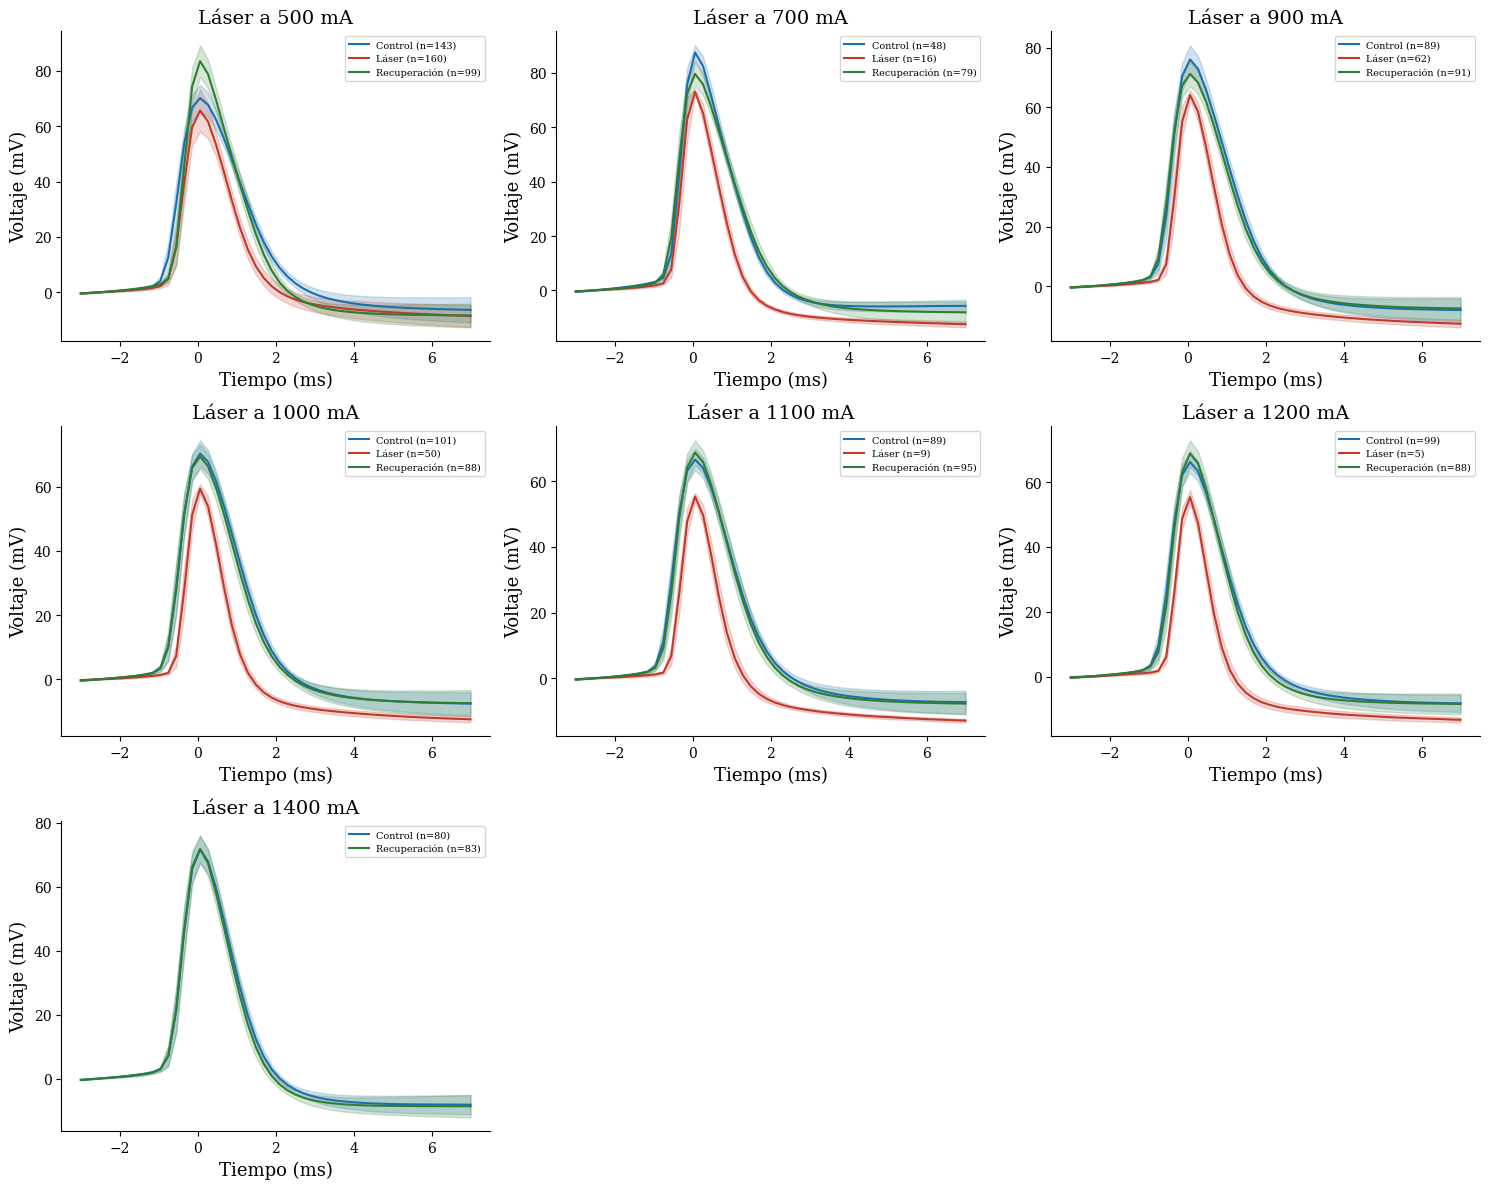

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, num in enumerate(archivos):
    abf = pyabf.ABF(rf"{ruta_base}\264270{num:02d}.abf")
    abf.setSweep(0, channel=0)
    tiempo, vm = abf.sweepX, abf.sweepY

    ax = axes[idx]

    for fase, color, label in [("control", colores["control"], "Control"),
                                ("laser", colores["laser"],"Láser"),
                                ("rec", colores["rec"], "Recuperación")]:
        t0 = archivos_info[num][fase][0]
        mask =(tiempo >= t0) & (tiempo <= t0 + FASE_DURACION)
        vm_fase = vm[mask]

        picos, _ = find_peaks(vm_fase, height=0, distance=int(0.05 * fs))

        lista = []
        for p in picos:
            recorte = vm_fase[p - muestras_antes : p + muestras_des]
            p_real  = p - muestras_antes + np.argmax(recorte)
            recorte = vm_fase[p_real - muestras_antes : p_real + muestras_des]
            lista.append(recorte - np.mean(recorte[:int(1 * fs / 1000)]))

        if len(lista)== 0:
            continue

        mat = np.vstack([s[:L] for s in lista])
        media = mat.mean(axis=0)
        std= mat.std(axis=0)

        ax.plot(t_eje, media, color=color, linewidth=1.5, label=f"{label} (n={mat.shape[0]})")
        ax.fill_between(t_eje, media - std, media + std, color=color, alpha=0.2)

    ax.set_title(f"Láser a {laser_ma[num]} mA", fontsize=14)
    ax.set_xlabel("Tiempo (ms)", fontsize=13)
    ax.set_ylabel("Voltaje (mV)", fontsize=13)
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[7].set_visible(False)
axes[8].set_visible(False)

plt.tight_layout()
plt.show()